# 🏃 RouteDoodle GNN — Shape-to-Route with Graph Neural Networks

> **Goal**: Draw any shape on an interactive map of **all of Houston, TX**, and get a
> real jogging route on actual streets that closely follows your drawing — powered
> by a **Graph Attention Network (GAT)**.

---

## Notebook Map

| # | Section | What Happens |
|---|---------|--------------|
| 1 | **Setup & Imports** | Install and import all libraries |
| 2 | **Full Houston Graph** | Download the entire Houston walk network + cache to disk |
| 3 | **Data Preprocessing** | Generate synthetic doodle→route training pairs |
| 4 | **Graph Construction** | Convert road subgraphs into PyTorch Geometric objects |
| 5 | **Model Definition** | GAT architecture that scores every road edge |
| 6 | **Training Loop** | Supervised training with weighted BCE loss |
| 7 | **🗺️ Interactive Drawing UI** | Draw on the map → run GNN + Dijkstra → see both routes |
| 8 | **Evaluation & Visualisation** | Fréchet distance comparison, side-by-side maps |
| 9 | **Scaling Notes** | Taking this to production |

---

### Why Upgrade from Dijkstra to a GNN?

| Aspect | Dijkstra (current `app.py`) | GNN (this notebook) |
|--------|---------------------------|---------------------|
| **Objective** | Shortest path between consecutive waypoints | Minimise *global* shape deviation |
| **Shape awareness** | None — stitches segments independently | Learns geometric similarity end-to-end |
| **Road preference** | Treats all roads equally (by length) | Can learn that parks/trails are better for jogging |
| **Speed** | Re-computes from scratch every time | Single forward pass (~ms) after training |
| **Adaptability** | Hard-coded heuristic | Fine-tunable on user feedback |

---
## 1 · Setup & Imports

| Library | Role |
|---------|------|
| **OSMnx** | Download real road networks from OpenStreetMap |
| **NetworkX** | Graph algorithms (Dijkstra baseline, connected components) |
| **PyTorch + PyG** | GNN model, graph data structures |
| **ipyleaflet** | Interactive map with drawing tools *inside Jupyter* |
| **Shapely** | Geometric distance calculations |
| **Matplotlib / Folium** | Static & interactive visualisation |

In [1]:
# ──────────────────────────────────────────────────────────────────
# 1.1  Install dependencies (uncomment & run once, then restart kernel)
# ──────────────────────────────────────────────────────────────────
!pip install osmnx networkx torch torch-geometric shapely
!pip install ipyleaflet ipywidgets folium matplotlib scikit-learn
# ──────────────────────────────────────────────────────────────────

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 179.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.5/342.5 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.5/32.5 MB 120.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 144.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.4/113.4 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.9/93.9 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 108.4 MB/s eta 0:00:00


In [2]:
# ──────────────────────────────────────────────────────────────────
# 1.2  Imports
# ──────────────────────────────────────────────────────────────────
from __future__ import annotations

import os, random, time, warnings, pickle
from math import atan2, cos, radians, sin, sqrt
from pathlib import Path

import folium
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from shapely.geometry import LineString, Point
from sklearn.model_selection import train_test_split

# Interactive map (works inside Jupyter notebooks)
import ipyleaflet as ipl
import ipywidgets as widgets
from IPython.display import display, HTML

# ── Reproducibility ───────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ All imports loaded  |  Device: {DEVICE}")

✅ All imports loaded  |  Device: cpu


---
## 1.3 · Persistent Storage Setup

When running on Colab, mount Google Drive once and keep the expensive artifacts
there so later sessions can reuse them.

Artifacts persisted here:
- `houston_walk_graph.graphml` — full Houston street graph cache
- `dataset_raw.pkl` — synthetic doodle→route samples
- `routegat_houston.pt` — trained model weights


In [3]:
# ──────────────────────────────────────────────────────────────────
# 1.3  Persistent storage setup (Google Drive on Colab)
# ──────────────────────────────────────────────────────────────────
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    DRIVE_ROOT = Path("/content/drive")
    if not (DRIVE_ROOT / "MyDrive").exists():
        drive.mount(str(DRIVE_ROOT))
    PERSIST_ROOT = DRIVE_ROOT / "MyDrive" / "RouteDoodle"
else:
    PERSIST_ROOT = Path("artifacts")

PERSIST_ROOT.mkdir(parents=True, exist_ok=True)

GRAPH_CACHE = PERSIST_ROOT / "houston_walk_graph.graphml"
DATASET_RAW_CACHE = PERSIST_ROOT / "dataset_raw.pkl"
CHECKPOINT_PATH = PERSIST_ROOT / "routegat_houston.pt"

print(f"Persistent storage root: {PERSIST_ROOT}")
print(f"Graph cache:            {GRAPH_CACHE}")
print(f"Raw dataset cache:      {DATASET_RAW_CACHE}")
print(f"Model checkpoint:       {CHECKPOINT_PATH}")


Mounted at /content/drive
Persistent storage root: /content/drive/MyDrive/RouteDoodle
Graph cache:            /content/drive/MyDrive/RouteDoodle/houston_walk_graph.graphml
Raw dataset cache:      /content/drive/MyDrive/RouteDoodle/dataset_raw.pkl
Model checkpoint:       /content/drive/MyDrive/RouteDoodle/routegat_houston.pt


---
## 2 · Download the Entire Houston Walk Network

Your original `app.py` downloaded a small radius around each doodle on-the-fly.
Here we download **all of Houston** once, cache it to disk, and extract local
subgraphs as needed. This means:

- **First run**: ~3–8 min download (Houston has ~200k+ walk nodes).
- **Every run after**: instant load from the cached `.graphml` file.
- **Drawing anywhere in Houston** works without re-downloading.

In [4]:
# ──────────────────────────────────────────────────────────────────
# 2.1  Download or load the cached Houston graph
# ──────────────────────────────────────────────────────────────────
if GRAPH_CACHE.exists():
    print(f"📂 Loading cached Houston graph from {GRAPH_CACHE} …")
    G_houston = ox.load_graphml(GRAPH_CACHE)
    print(f"   Loaded in cache.")
else:
    print("🌐 Downloading full Houston walk network (this takes a few minutes) …")
    t0 = time.time()
    G_houston = ox.graph_from_place(
        "Houston, Texas, USA",
        network_type="walk",
        retain_all=False,
        truncate_by_edge=True,
    )
    elapsed = time.time() - t0
    print(f"   Downloaded in {elapsed:.0f}s — saving to {GRAPH_CACHE} …")
    ox.save_graphml(G_houston, GRAPH_CACHE)

# Prune to the largest connected component (same fix as your app.py)
G_houston = G_houston.subgraph(
    max(nx.weakly_connected_components(G_houston), key=len)
).copy()

print(f"✅ Houston graph: {G_houston.number_of_nodes():,} nodes, "
      f"{G_houston.number_of_edges():,} edges")

📂 Loading cached Houston graph from /content/drive/MyDrive/RouteDoodle/houston_walk_graph.graphml …
   Loaded in cache.
✅ Houston graph: 257,527 nodes, 739,538 edges


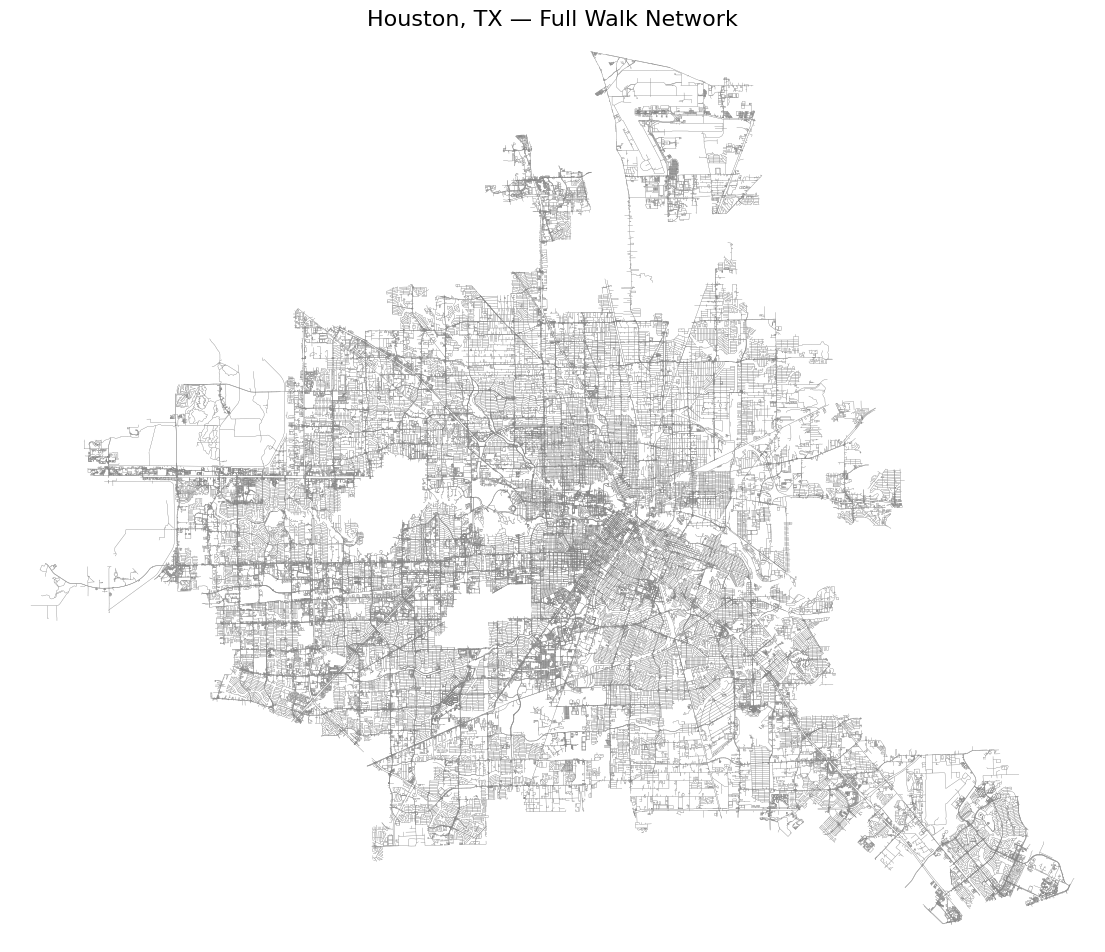

In [5]:
# ──────────────────────────────────────────────────────────────────
# 2.2  Quick plot — the full Houston street network
# ──────────────────────────────────────────────────────────────────
fig, ax = ox.plot_graph(
    G_houston, figsize=(14, 14), node_size=0,
    edge_linewidth=0.15, bgcolor="white", edge_color="#888",
    show=False, close=False,
)
ax.set_title("Houston, TX — Full Walk Network", fontsize=16)
plt.show()

In [6]:
# ──────────────────────────────────────────────────────────────────
# 2.3  Extract a local subgraph around a bounding box
#      (same logic as get_graph() in your app.py, but pulling
#       from the cached full graph instead of re-downloading)
# ──────────────────────────────────────────────────────────────────

def extract_subgraph(G_full, latlon_pts: list, padding_m: int = 800):
    """
    Extract the portion of the full Houston graph that covers
    the user's doodle, with padding for routing room.
    """
    lats = [p[0] for p in latlon_pts]
    lons = [p[1] for p in latlon_pts]
    clat = (min(lats) + max(lats)) / 2
    clon = (min(lons) + max(lons)) / 2

    # Bounding box half-diagonal + padding
    dlat_m = (max(lats) - min(lats)) * 111_000
    dlon_m = (max(lons) - min(lons)) * 111_000 * cos(radians(clat))
    radius_m = int(sqrt(dlat_m**2 + dlon_m**2) / 2) + padding_m
    radius_m = max(radius_m, 800)

    # Find the nearest actual graph node to the centre point,
    # then truncate by distance from that node
    center_node = ox.distance.nearest_nodes(G_full, clon, clat)
    G_sub = ox.truncate.truncate_graph_dist(G_full, center_node, radius_m)

    # Prune to largest connected component
    if G_sub.number_of_nodes() > 0:
        G_sub = G_sub.subgraph(
            max(nx.weakly_connected_components(G_sub), key=len)
        ).copy()

    return G_sub


# Quick test: extract a 2km subgraph around downtown Houston
test_pts = [(29.760, -95.370), (29.755, -95.360)]
G_test = extract_subgraph(G_houston, test_pts)
print(f"Subgraph test: {G_test.number_of_nodes()} nodes, {G_test.number_of_edges()} edges")

Subgraph test: 2869 nodes, 8700 edges


---
## 3 · Data Preprocessing — Synthetic Training Pairs

### The Problem
No public dataset of "hand-drawn shapes + ideal jogging routes" exists.

### Our Solution
Generate synthetic pairs from the real Houston road graph:

1. **Sample** two distant nodes → Dijkstra shortest path = **ground truth route**
2. **Perturb** the route with Gaussian noise = **simulated doodle**
3. **Label** every edge: `1` if on the route, `0` otherwise

This gives us `(doodle, road_graph) → edge_labels` for supervised training.

In [7]:
# ──────────────────────────────────────────────────────────────────
# 3.1  Geometry helpers (carried over from your app.py)
# ──────────────────────────────────────────────────────────────────

def haversine_m(p1: tuple, p2: tuple) -> float:
    """Great-circle distance in metres between two (lat, lon) points."""
    R = 6_371_000.0
    lat1, lon1, lat2, lon2 = map(radians, (*p1, *p2))
    a = sin((lat2 - lat1) / 2) ** 2 + cos(lat1) * cos(lat2) * sin((lon2 - lon1) / 2) ** 2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))


def _perp_dist(pt, s, e):
    """Perpendicular distance (metres) from pt to segment s→e."""
    if s == e:
        return haversine_m(pt, s)
    R, lat0 = 6_371_000.0, radians(s[0])
    def xy(p):
        return radians(p[1] - s[1]) * R * cos(lat0), radians(p[0] - s[0]) * R
    ax, ay = xy(s)
    bx, by = xy(e)
    px, py = xy(pt)
    dx, dy = bx - ax, by - ay
    t = max(0.0, min(1.0, ((px - ax) * dx + (py - ay) * dy) / (dx * dx + dy * dy)))
    return sqrt((px - ax - t * dx) ** 2 + (py - ay - t * dy) ** 2)


def rdp_simplify(pts: list, eps_m: float = 20.0) -> list:
    """
    Ramer-Douglas-Peucker simplification (from your app.py).
    Keeps corners, drops redundant points on straight stretches.
    """
    if len(pts) < 3:
        return list(pts)
    n = len(pts)
    keep = [False] * n
    keep[0] = keep[-1] = True
    stack = [(0, n - 1)]
    while stack:
        s, e = stack.pop()
        md_val, mi = 0.0, s
        for i in range(s + 1, e):
            d = _perp_dist(pts[i], pts[s], pts[e])
            if d > md_val:
                md_val, mi = d, i
        if md_val > eps_m:
            keep[mi] = True
            stack += [(s, mi), (mi, e)]
    return [p for i, p in enumerate(pts) if keep[i]]


def route_km(coords: list) -> float:
    """Total route length in kilometres."""
    return sum(haversine_m(coords[i], coords[i + 1])
               for i in range(len(coords) - 1)) / 1000.0


print("✅ Geometry helpers ready")

✅ Geometry helpers ready


In [10]:
# ──────────────────────────────────────────────────────────────────
# 3.2  Generate synthetic training samples
# ──────────────────────────────────────────────────────────────────

N_SAMPLES     = 200      # Total training + validation pairs
MIN_DIST_M    = 800      # Min straight-line distance for route endpoints
MAX_DIST_M    = 3000     # Max distance (longer routes across Houston)
DOODLE_NOISE  = 0.00035  # Gaussian σ in degrees (~35m) for doodle perturbation

nodes_list = list(G_houston.nodes)

def random_route_pair(G, nodes, min_d=MIN_DIST_M, max_d=MAX_DIST_M, max_tries=300):
    """
    Generate one (doodle, ground_truth_route) training pair.

    Returns:
        route_edges   : set of (u, v) — edges on the ground-truth path
        doodle_coords : list of (lat, lon) — noisy simulated drawing
        route_coords  : list of (lat, lon) — clean ground-truth route
        subgraph      : NetworkX subgraph around this route
    """
    for _ in range(max_tries):
        src, tgt = random.sample(nodes, 2)
        p1 = (G.nodes[src]["y"], G.nodes[src]["x"])
        p2 = (G.nodes[tgt]["y"], G.nodes[tgt]["x"])
        d = haversine_m(p1, p2)
        if not (min_d <= d <= max_d):
            continue
        try:
            path_nodes = nx.shortest_path(G, src, tgt, weight="length")
        except nx.NetworkXNoPath:
            continue
        if len(path_nodes) < 5:
            continue

        # Route coordinates and edges
        route_coords = [(G.nodes[n]["y"], G.nodes[n]["x"]) for n in path_nodes]
        route_edges = set()
        for i in range(len(path_nodes) - 1):
            route_edges.add((path_nodes[i], path_nodes[i + 1]))
            route_edges.add((path_nodes[i + 1], path_nodes[i]))

        # Extract the local subgraph for this sample
        subgraph = extract_subgraph(G, route_coords, padding_m=600)
        if subgraph.number_of_nodes() < 20:
            continue

        # Perturb route → simulated doodle
        doodle_coords = [
            (lat + np.random.normal(0, DOODLE_NOISE),
             lon + np.random.normal(0, DOODLE_NOISE))
            for lat, lon in route_coords
        ]

        return route_edges, doodle_coords, route_coords, subgraph

    return None


# ── Generate all samples or load the cached dataset ──────────────
if DATASET_RAW_CACHE.exists():
    print(f"📂 Loading cached synthetic dataset from {DATASET_RAW_CACHE} …")
    with open(DATASET_RAW_CACHE, "rb") as f:
        dataset_raw = pickle.load(f)
    print(f"✅ Loaded {len(dataset_raw)} cached samples")
else:
    print(f"Generating {N_SAMPLES} synthetic (doodle → route) pairs across Houston …")
    dataset_raw = []
    attempts = 0

    while len(dataset_raw) < N_SAMPLES and attempts < N_SAMPLES * 5:
        result = random_route_pair(G_houston, nodes_list)
        attempts += 1
        if result is not None:
            dataset_raw.append(result)
            if len(dataset_raw) % 1 == 0:
                print(f"  {len(dataset_raw)}/{N_SAMPLES} samples …")

    with open(DATASET_RAW_CACHE, "wb") as f:
        pickle.dump(dataset_raw, f)
    print(f"✅ Generated {len(dataset_raw)} samples (from {attempts} attempts)")
    print(f"   Saved dataset cache to {DATASET_RAW_CACHE}")

Generating 200 synthetic (doodle → route) pairs across Houston …
  1/200 samples …
  2/200 samples …
  3/200 samples …
  4/200 samples …
  5/200 samples …
  6/200 samples …
  7/200 samples …
  8/200 samples …
  9/200 samples …
  10/200 samples …
  11/200 samples …
  12/200 samples …
  13/200 samples …
  14/200 samples …
  15/200 samples …
  16/200 samples …
  17/200 samples …
  18/200 samples …
  19/200 samples …
  20/200 samples …
  21/200 samples …
  22/200 samples …
  23/200 samples …
  24/200 samples …
  25/200 samples …
  26/200 samples …
  27/200 samples …
  28/200 samples …
  29/200 samples …
  30/200 samples …
  31/200 samples …
  32/200 samples …
  33/200 samples …
  34/200 samples …
  35/200 samples …
  36/200 samples …
  37/200 samples …
  38/200 samples …
  39/200 samples …
  40/200 samples …
  41/200 samples …
  42/200 samples …
  43/200 samples …
  44/200 samples …
  45/200 samples …
  46/200 samples …
  47/200 samples …
  48/200 samples …
  49/200 samples …
  50/200 samp

---
## 4 · Graph Construction for PyTorch Geometric

Each training sample becomes a PyG `Data` object encoding:

### Node Features (per intersection)
| # | Feature | Why |
|---|---------|-----|
| 1 | Distance to doodle | Core signal — "is this node near the drawn shape?" |
| 2 | Normalised latitude | Spatial awareness |
| 3 | Normalised longitude | Spatial awareness |
| 4 | Node degree | Intersection complexity (dead-end vs crossing) |

### Edge Features (per road segment)
| # | Feature | Why |
|---|---------|-----|
| 1 | Normalised length | Prefer shorter segments for efficient routes |

### Labels
Per-edge binary: `1` = on ground-truth route, `0` = not.

In [11]:
# ──────────────────────────────────────────────────────────────────
# 4.1  Convert one sample → PyG Data object
# ──────────────────────────────────────────────────────────────────

def point_to_line_distance(lat, lon, doodle_coords):
    """Distance (degrees) from a point to the doodle polyline."""
    if len(doodle_coords) < 2:
        return 1.0
    line = LineString([(lo, la) for la, lo in doodle_coords])
    return line.distance(Point(lon, lat))


def build_pyg_data(G_sub, route_edges: set, doodle_coords: list) -> Data:
    """
    Convert a (subgraph, route_edges, doodle) triplet into a PyG Data object.

    This is the heart of the data pipeline — it takes the road network
    and the drawn shape, and produces the tensor representation the GNN needs.
    """
    node_list = list(G_sub.nodes)
    node_to_idx = {n: i for i, n in enumerate(node_list)}
    num_nodes = len(node_list)

    # Normalisation stats for this subgraph
    lats = np.array([G_sub.nodes[n]["y"] for n in node_list])
    lons = np.array([G_sub.nodes[n]["x"] for n in node_list])
    lat_mean, lat_std = lats.mean(), max(lats.std(), 1e-8)
    lon_mean, lon_std = lons.mean(), max(lons.std(), 1e-8)

    # ── Node features ─────────────────────────────────────────────
    node_features = []
    for n in node_list:
        lat, lon = G_sub.nodes[n]["y"], G_sub.nodes[n]["x"]
        dist = point_to_line_distance(lat, lon, doodle_coords)
        node_features.append([
            dist,                               # 0: distance to doodle
            (lat - lat_mean) / lat_std,          # 1: normalised lat
            (lon - lon_mean) / lon_std,          # 2: normalised lon
            G_sub.degree(n),                     # 3: degree
        ])

    x = torch.tensor(node_features, dtype=torch.float)
    # Normalise distance and degree to [0, 1]
    for col in [0, 3]:
        if x[:, col].max() > 0:
            x[:, col] = x[:, col] / x[:, col].max()

    # ── Edge index, features, labels ──────────────────────────────
    src_list, dst_list, e_feats, e_labels = [], [], [], []

    for u, v, data in G_sub.edges(data=True):
        if u not in node_to_idx or v not in node_to_idx:
            continue
        src_list.append(node_to_idx[u])
        dst_list.append(node_to_idx[v])
        e_feats.append([data.get("length", 50.0) / 500.0])
        e_labels.append(1.0 if (u, v) in route_edges else 0.0)

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_attr  = torch.tensor(e_feats, dtype=torch.float)
    edge_y     = torch.tensor(e_labels, dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr,
                edge_y=edge_y, num_nodes=num_nodes)

In [12]:
# ──────────────────────────────────────────────────────────────────
# 4.2  Build the full PyG dataset
# ──────────────────────────────────────────────────────────────────
print("Converting samples to PyG graph objects …")
pyg_dataset = []

for idx, (route_edges, doodle_coords, route_coords, subgraph) in enumerate(dataset_raw):
    data = build_pyg_data(subgraph, route_edges, doodle_coords)
    # Stash original coords and subgraph ref for visualisation later
    data.doodle_coords = doodle_coords
    data.route_coords  = route_coords
    data.subgraph_ref  = subgraph
    pyg_dataset.append(data)

    if (idx + 1) % 50 == 0:
        print(f"  {idx + 1}/{len(dataset_raw)} …")

print(f"\n✅ Dataset: {len(pyg_dataset)} samples")
print(f"   Example — nodes: {pyg_dataset[0].num_nodes}, "
      f"edges: {pyg_dataset[0].edge_index.shape[1]}, "
      f"positive ratio: {pyg_dataset[0].edge_y.mean():.3f}")

Converting samples to PyG graph objects …
  50/200 …
  100/200 …
  150/200 …
  200/200 …

✅ Dataset: 200 samples
   Example — nodes: 705, edges: 1890, positive ratio: 0.059


In [13]:
# ──────────────────────────────────────────────────────────────────
# 4.3  Train / Validation split
# ──────────────────────────────────────────────────────────────────
train_data, val_data = train_test_split(pyg_dataset, test_size=0.2, random_state=SEED)
print(f"Training:   {len(train_data)} samples")
print(f"Validation: {len(val_data)} samples")

Training:   160 samples
Validation: 40 samples


---
## 5 · Model Definition — Graph Attention Network (GAT)

### Why GAT?

- **GCN** averages all neighbours equally → can't focus on doodle-adjacent nodes.
- **GAT** learns *attention weights* → dynamically focuses on the nodes that matter
  most for route prediction. A node right on the doodle line will receive more
  attention than a distant one.

### Architecture

```
Road graph + doodle features
  │
  ├─ GAT Layer 1  (4 → 64, 4 attention heads)
  ├─ GAT Layer 2  (256 → 64, 4 heads)
  ├─ GAT Layer 3  (256 → 64, 2 heads, averaged)
  │
  └─ Edge Scorer MLP
       concat(node_u, node_v, edge_length) → 129-dim
       → Linear(64) → ReLU
       → Linear(32) → ReLU
       → Linear(1)  → sigmoid → P(edge on route)
```

In [14]:
# ──────────────────────────────────────────────────────────────────
# 5.1  RouteGAT model
# ──────────────────────────────────────────────────────────────────

class RouteGAT(nn.Module):
    """
    3-layer GAT that produces per-edge probabilities:
    "How likely is this road segment to be part of the ideal route?"
    """

    def __init__(self, in_channels=4, hidden=64, heads1=4, heads2=2,
                 edge_feat_dim=1, dropout=0.2):
        super().__init__()

        # GAT backbone — progressively expands the receptive field
        self.gat1 = GATConv(in_channels,     hidden, heads=heads1, concat=True,  dropout=dropout)
        self.gat2 = GATConv(hidden * heads1,  hidden, heads=heads1, concat=True,  dropout=dropout)
        self.gat3 = GATConv(hidden * heads1,  hidden, heads=heads2, concat=False, dropout=dropout)

        # Edge scoring MLP: takes (src_embed ‖ dst_embed ‖ edge_feats)
        self.edge_mlp = nn.Sequential(
            nn.Linear(hidden * 2 + edge_feat_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )
        self.dropout = dropout

    def forward(self, data):
        x, ei, ea = data.x, data.edge_index, data.edge_attr

        # Node embeddings through 3 GAT layers
        x = F.elu(self.gat1(x, ei))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.gat2(x, ei))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat3(x, ei)                    # [N, hidden]

        # Score each edge
        src, dst = ei[0], ei[1]
        edge_repr = torch.cat([x[src], x[dst], ea], dim=1)
        return torch.sigmoid(self.edge_mlp(edge_repr).squeeze(-1))


model = RouteGAT().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ RouteGAT — {n_params:,} trainable parameters")
print(model)

✅ RouteGAT — 111,617 trainable parameters
RouteGAT(
  (gat1): GATConv(4, 64, heads=4)
  (gat2): GATConv(256, 64, heads=4)
  (gat3): GATConv(256, 64, heads=2)
  (edge_mlp): Sequential(
    (0): Linear(in_features=129, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


---
## 5.2 Optional Checkpoint Restore

If you are running on Colab and want the trained model to persist across sessions,
mount Google Drive and run the next code cell before Section 6. If a checkpoint
already exists, the notebook loads it and you can skip retraining.


In [15]:
# ──────────────────────────────────────────────────────────────────
# 5.2  Optional checkpoint restore (Colab-friendly)
# ──────────────────────────────────────────────────────────────────
SKIP_TRAINING = False
checkpoint_meta = None

if CHECKPOINT_PATH.exists():
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(DEVICE)
    model.eval()
    checkpoint_meta = checkpoint.get("meta", {})
    SKIP_TRAINING = True
    print(f"Loaded checkpoint from {CHECKPOINT_PATH}")
    print("Checkpoint found: you can skip Section 6 and go straight to Section 7.")
else:
    print(f"No checkpoint found at {CHECKPOINT_PATH}")
    print("Train the model in Section 6, then run the save cell once.")


No checkpoint found at /content/drive/MyDrive/RouteDoodle/routegat_houston.pt
Train the model in Section 6, then run the save cell once.


---
## 6 · Training Loop

**Key challenge**: Route edges are only ~2–5% of all edges in a subgraph.
Without class weighting the model would just predict `0` everywhere and
get 95%+ accuracy. We fix this with **weighted BCE loss** — positive
(on-route) edges get 15× the loss weight.

In [16]:
# ──────────────────────────────────────────────────────────────────
# 6.1  Training configuration
# ──────────────────────────────────────────────────────────────────
EPOCHS       = 60
LR           = 1e-3
WEIGHT_DECAY = 1e-4
POS_WEIGHT   = 15.0   # Upweight the rare "on-route" edges

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
criterion = nn.BCELoss(reduction="none")

In [17]:
# ──────────────────────────────────────────────────────────────────
# 6.2  Training loop
# ──────────────────────────────────────────────────────────────────

def compute_loss(preds, targets):
    weights = torch.where(targets == 1.0, POS_WEIGHT, 1.0)
    return (criterion(preds, targets) * weights).mean()

def evaluate(dataset):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for d in dataset:
            d = d.to(DEVICE)
            p = model(d)
            total_loss += compute_loss(p, d.edge_y).item()
            correct += ((p > 0.5).float() == d.edge_y).sum().item()
            total += d.edge_y.numel()
    return total_loss / len(dataset), correct / total


train_losses, val_losses = [], []

if SKIP_TRAINING:
    print("Checkpoint already loaded: skipping training.")
else:
    print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Val Loss':>10}  {'Val Acc':>8}")
    print("─" * 45)

    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_loss = 0.0
        random.shuffle(train_data)

        for d in train_data:
            d = d.to(DEVICE)
            optimizer.zero_grad()
            loss = compute_loss(model(d), d.edge_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()

        scheduler.step()
        avg_train = epoch_loss / len(train_data)
        avg_val, val_acc = evaluate(val_data)
        train_losses.append(avg_train)
        val_losses.append(avg_val)

        if epoch % 5 == 0 or epoch == 1:
            print(f"{epoch:>5d}  {avg_train:>10.4f}  {avg_val:>10.4f}  {val_acc:>7.1%}")

    print("\n✅ Training complete!")

Epoch  Train Loss    Val Loss   Val Acc
─────────────────────────────────────────────
    1      0.5340      0.4309    89.7%
    5      0.3607      0.4510    92.5%
   10      0.3274      0.3567    92.4%
   15      0.3170      0.3396    91.4%
   20      0.3031      0.3225    92.2%
   25      0.2882      0.3043    92.1%
   30      0.2995      0.3061    92.1%
   35      0.2880      0.3014    92.0%
   40      0.2918      0.3111    92.0%
   45      0.2843      0.3001    91.8%
   50      0.2775      0.2825    90.9%
   55      0.2760      0.2826    91.1%
   60      0.2810      0.2973    92.1%

✅ Training complete!


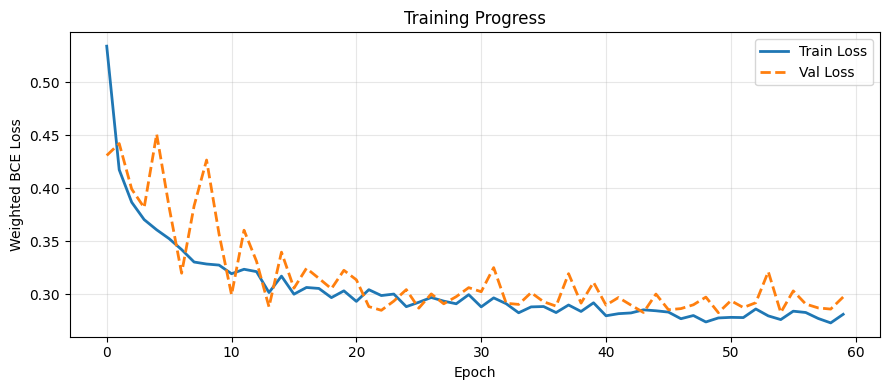

In [18]:
# ──────────────────────────────────────────────────────────────────
# 6.3  Training curves
# ──────────────────────────────────────────────────────────────────
if train_losses:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(train_losses, label="Train Loss", linewidth=2)
    ax.plot(val_losses, label="Val Loss", linewidth=2, linestyle="--")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Weighted BCE Loss")
    ax.set_title("Training Progress")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Training curves are unavailable because this session loaded a saved checkpoint.")

---
## 6.4 Save Trained Weights

Run the next cell after training to save the model weights. On Colab, the
checkpoint is written to Google Drive so it persists after the runtime stops.


In [19]:
# ──────────────────────────────────────────────────────────────────
# 6.4  Save trained weights
# ──────────────────────────────────────────────────────────────────
def save_checkpoint(path=CHECKPOINT_PATH):
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "meta": {
            "device": str(DEVICE),
            "seed": SEED,
            "n_samples": len(pyg_dataset),
            "train_size": len(train_data),
            "val_size": len(val_data),
            "graph_cache": str(GRAPH_CACHE),
            "dataset_raw_cache": str(DATASET_RAW_CACHE),
        },
    }
    torch.save(checkpoint, path)
    print(f"Saved checkpoint to {path}")
    return path

if train_losses:
    save_checkpoint()
else:
    print(f"Checkpoint path: {CHECKPOINT_PATH}")
    print("Training was skipped in this session. Call save_checkpoint() later if you fine-tune the model.")

Saved checkpoint to /content/drive/MyDrive/RouteDoodle/routegat_houston.pt


---
## 7 · 🗺️ Interactive Drawing UI

This replicates your Streamlit `app.py` drawing experience **inside the notebook**.

### How it works
1. An interactive map of Houston appears below with a **drawing toolbar**.
2. Use the **polyline tool** (the bent-line icon) to draw any shape.
3. Click **"🔴 Snap with GNN"** or **"🔵 Snap with Dijkstra"** to generate routes.
4. Both routes appear overlaid on the map with distance stats.

> Uses `ipyleaflet` with `DrawControl` — drawing coordinates flow directly
> back to Python, no copy-pasting needed.

In [20]:
# ──────────────────────────────────────────────────────────────────
# 7.1  Inference functions
# ──────────────────────────────────────────────────────────────────

def dijkstra_route(G, waypoints):
    """Original Dijkstra routing from your app.py."""
    lats = [p[0] for p in waypoints]
    lons = [p[1] for p in waypoints]
    node_ids = ox.distance.nearest_nodes(G, lons, lats)

    unique = [node_ids[0]]
    for nid in node_ids[1:]:
        if nid != unique[-1]:
            unique.append(nid)

    route = []
    for i in range(len(unique) - 1):
        try:
            path = nx.shortest_path(G, unique[i], unique[i + 1], weight="length")
            seg = [(G.nodes[n]["y"], G.nodes[n]["x"]) for n in path]
            route.extend(seg[1:] if route else seg)
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            continue
    return route


def gnn_predict_route(model, G_sub, doodle_coords, threshold=0.4):
    """
    GNN inference: doodle → edge probabilities → stitched route.

    1. Build PyG data from subgraph + doodle features
    2. Forward pass → per-edge probability
    3. Keep high-prob edges, find shortest path through them
    """
    model.eval()
    data = build_pyg_data(G_sub, set(), doodle_coords).to(DEVICE)

    with torch.no_grad():
        edge_probs = model(data).cpu().numpy()

    ei = data.edge_index.cpu().numpy()
    node_list = list(G_sub.nodes)

    # Build subgraph of high-probability edges
    H = nx.DiGraph()
    for k in range(ei.shape[1]):
        if edge_probs[k] >= threshold:
            u_osm = node_list[ei[0, k]]
            v_osm = node_list[ei[1, k]]
            H.add_edge(u_osm, v_osm, weight=1.0 - edge_probs[k])

    if H.number_of_edges() == 0:
        return dijkstra_route(G_sub, doodle_coords)

    # Snap doodle start/end to subgraph nodes
    sub_nodes = list(H.nodes)
    def nearest(lat, lon, ns):
        return min(ns, key=lambda n: haversine_m(
            (lat, lon), (G_sub.nodes[n]["y"], G_sub.nodes[n]["x"])))

    src = nearest(*doodle_coords[0], sub_nodes)
    tgt = nearest(*doodle_coords[-1], sub_nodes)

    try:
        path = nx.shortest_path(H, src, tgt, weight="weight")
        return [(G_sub.nodes[n]["y"], G_sub.nodes[n]["x"]) for n in path]
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        return dijkstra_route(G_sub, doodle_coords)

In [ ]:
# ──────────────────────────────────────────────────────────────────
# 7.2  Build the interactive drawing map
# ──────────────────────────────────────────────────────────────────

# ── Map centred on Houston ────────────────────────────────────────
houston_map = ipl.Map(
    center=(29.7604, -95.3698),
    zoom=12,
    layout=widgets.Layout(width="100%", height="600px"),
    basemap=ipl.basemaps.CartoDB.Positron,
)

# ── Drawing toolbar (polyline only, like your app.py) ─────────────
draw_control = ipl.DrawControl(
    polyline={
        "shapeOptions": {"color": "#2074b6", "weight": 3, "opacity": 0.85}
    },
    polygon={},        # disabled
    circle={},         # disabled
    rectangle={},      # disabled
    marker={},         # disabled
    circlemarker={},   # disabled
)
houston_map.add(draw_control)

# ── Layer groups for routes ───────────────────────────────────────
route_layers = ipl.LayerGroup(name="Routes")
houston_map.add(route_layers)

# ── Output area for stats ─────────────────────────────────────────
output = widgets.Output()

# ── State ─────────────────────────────────────────────────────────
drawn_coords = []   # Will hold the latest doodle as [(lat, lon), ...]

def on_draw(self, action, geo_json):
    """Capture drawn polyline coordinates."""
    global drawn_coords
    if geo_json["geometry"]["type"] == "LineString":
        # GeoJSON is [lon, lat] → flip to (lat, lon)
        drawn_coords = [
            (c[1], c[0]) for c in geo_json["geometry"]["coordinates"]
        ]
        with output:
            output.clear_output()
            print(f"✏️  Doodle captured: {len(drawn_coords)} points")

draw_control.on_draw(on_draw)


# ── Buttons ───────────────────────────────────────────────────────
btn_gnn = widgets.Button(
    description="🔴 Snap with GNN",
    button_style="danger",
    layout=widgets.Layout(width="180px", height="36px"),
)
btn_dij = widgets.Button(
    description="🔵 Snap with Dijkstra",
    button_style="primary",
    layout=widgets.Layout(width="180px", height="36px"),
)
btn_clear = widgets.Button(
    description="🗑️ Clear",
    button_style="warning",
    layout=widgets.Layout(width="120px", height="36px"),
)
btn_both = widgets.Button(
    description="⚡ Both (compare)",
    button_style="success",
    layout=widgets.Layout(width="180px", height="36px"),
)


def add_route_to_map(coords, color, name):
    """Add a polyline route to the map."""
    line = ipl.Polyline(
        locations=coords,
        color=color,
        weight=5 if color == "#E84545" else 4,
        opacity=0.9,
        name=name,
    )
    route_layers.add(line)
    # Start marker
    route_layers.add(ipl.Marker(
        location=coords[0],
        icon=ipl.AwesomeIcon(name="play", marker_color="green"),
        title="Start",
    ))
    # End marker
    route_layers.add(ipl.Marker(
        location=coords[-1],
        icon=ipl.AwesomeIcon(name="flag-checkered", marker_color="red"),
        title="End",
    ))


def run_snap(method="both"):
    global drawn_coords
    with output:
        output.clear_output()
        if not drawn_coords or len(drawn_coords) < 2:
            print("⚠️  Draw a polyline first! Use the line tool in the top-left toolbar.")
            return

        # RDP simplify (same as your app.py)
        simplified = rdp_simplify(drawn_coords, eps_m=20.0)
        if len(simplified) < 2:
            print("⚠️  Drawing too short — draw a longer line.")
            return

        # Extract local subgraph from the full Houston graph
        print(f"📍 Doodle: {len(drawn_coords)} pts → {len(simplified)} after RDP")
        print("🔍 Extracting local road network …")
        G_local = extract_subgraph(G_houston, drawn_coords, padding_m=800)
        print(f"   Subgraph: {G_local.number_of_nodes()} nodes, {G_local.number_of_edges()} edges")

        # Clear old routes
        route_layers.clear_layers()

        if method in ("gnn", "both"):
            print("🧠 Running GNN inference …")
            t0 = time.time()
            gnn_route = gnn_predict_route(model, G_local, simplified)
            gnn_time = time.time() - t0
            if gnn_route:
                add_route_to_map(gnn_route, "#E84545", "GNN Route")
                km = route_km(gnn_route)
                print(f"   🔴 GNN route: {km:.2f} km ({km*0.6214:.2f} mi) — {gnn_time:.2f}s")

        if method in ("dijkstra", "both"):
            print("📐 Running Dijkstra …")
            t0 = time.time()
            dij_route = dijkstra_route(G_local, simplified)
            dij_time = time.time() - t0
            if dij_route:
                add_route_to_map(dij_route, "#27ae60", "Dijkstra Route")
                km = route_km(dij_route)
                print(f"   🔵 Dijkstra route: {km:.2f} km ({km*0.6214:.2f} mi) — {dij_time:.2f}s")

        print("\n✅ Done! Routes displayed on map.")


btn_gnn.on_click(lambda _: run_snap("gnn"))
btn_dij.on_click(lambda _: run_snap("dijkstra"))
btn_both.on_click(lambda _: run_snap("both"))

def clear_all(_):
    global drawn_coords
    drawn_coords = []
    route_layers.clear_layers()
    draw_control.clear()
    with output:
        output.clear_output()
        print("🗑️ Cleared.")

btn_clear.on_click(clear_all)

print("✅ Interactive map ready — run the next cell to display it.")

✅ Interactive map ready — run the next cell to display it.


In [27]:
# ──────────────────────────────────────────────────────────────────
# 7.3  Display the interactive map
# ──────────────────────────────────────────────────────────────────
#
# WORKFLOW (same as your Streamlit app!):
#   1. Use the polyline tool (top-left toolbar) to draw any shape
#   2. Click one of the snap buttons below the map
#   3. Routes appear on the map with stats printed below
#
# ──────────────────────────────────────────────────────────────────

display(HTML("""
<div style="background:#f8f9fa; padding:12px 16px; border-radius:8px;
            border-left:4px solid #E84545; margin-bottom:8px; font-size:14px;">
    <b>🏃 RouteDoodle GNN</b> — Draw any shape on the map below, then click a button to snap it to real Houston streets.<br>
    <span style="color:#E84545;">━━━</span> GNN Route &nbsp;
    <span style="color:#27ae60;">━━━</span> Dijkstra Route &nbsp;
    <span style="color:#2074b6;">━ ━</span> Your Doodle
</div>
"""))

button_bar = widgets.HBox([btn_gnn, btn_dij, btn_both, btn_clear])
display(houston_map)
display(button_bar)
display(output)

Map(bottom=3469417.0, center=[29.69532248729188, -95.36042690277101], controls=(ZoomControl(options=['position…

Output()

---
## 8 · Evaluation & Visualisation

We compare both approaches on the held-out validation set using:

- **Fréchet Distance** — measures geometric similarity between the predicted
  route and the original doodle (lower = closer shape match)
- **Visual comparison** — side-by-side matplotlib plots

In [23]:
# ──────────────────────────────────────────────────────────────────
# 8.1  Discrete Fréchet Distance
# ──────────────────────────────────────────────────────────────────

def discrete_frechet(P, Q):
    """Discrete Fréchet distance (metres) between two polylines."""
    n, m = len(P), len(Q)
    if n == 0 or m == 0:
        return float("inf")
    ca = np.full((n, m), -1.0)
    for i in range(n):
        for j in range(m):
            d = haversine_m(P[i], Q[j])
            if i == 0 and j == 0:
                ca[i, j] = d
            elif i == 0:
                ca[i, j] = max(ca[i, j - 1], d)
            elif j == 0:
                ca[i, j] = max(ca[i - 1, j], d)
            else:
                ca[i, j] = max(min(ca[i-1, j], ca[i-1, j-1], ca[i, j-1]), d)
    return ca[n - 1, m - 1]

In [24]:
# ──────────────────────────────────────────────────────────────────
# 8.2  Benchmark on validation set
# ──────────────────────────────────────────────────────────────────

N_EVAL = min(15, len(val_data))
frechet_gnn, frechet_dij = [], []

print(f"Evaluating {N_EVAL} validation samples …\n")
print(f"{'#':>3}  {'GNN (m)':>8}  {'Dijkstra (m)':>12}  {'Winner':>8}")
print("─" * 40)

for i in range(N_EVAL):
    sample = val_data[i]
    doodle = sample.doodle_coords
    G_local = sample.subgraph_ref

    gnn_r = gnn_predict_route(model, G_local, doodle)
    dij_r = dijkstra_route(G_local, doodle)

    fd_g = discrete_frechet(doodle, gnn_r) if gnn_r else float("inf")
    fd_d = discrete_frechet(doodle, dij_r) if dij_r else float("inf")
    frechet_gnn.append(fd_g)
    frechet_dij.append(fd_d)

    winner = "GNN" if fd_g < fd_d else "Dijkstra"
    print(f"{i+1:>3}  {fd_g:>8.0f}  {fd_d:>12.0f}  {winner:>8}")

print(f"\n{'═'*40}")
print(f"Average Fréchet:  GNN = {np.mean(frechet_gnn):.0f}m  |  Dijkstra = {np.mean(frechet_dij):.0f}m")
gnn_wins = sum(1 for g, d in zip(frechet_gnn, frechet_dij) if g < d)
print(f"GNN wins {gnn_wins}/{N_EVAL} samples")

Evaluating 15 validation samples …

  #   GNN (m)  Dijkstra (m)    Winner
────────────────────────────────────────
  1       105           123       GNN
  2        89            89  Dijkstra
  3       898           825  Dijkstra
  4       105           126       GNN
  5       304           304  Dijkstra
  6       117           321       GNN
  7       119            79  Dijkstra
  8       645           645  Dijkstra
  9       132           123  Dijkstra
 10       112           112  Dijkstra
 11       680           680  Dijkstra
 12       475           732       GNN
 13       104           184       GNN
 14        97            84  Dijkstra
 15       192            88  Dijkstra

════════════════════════════════════════
Average Fréchet:  GNN = 278m  |  Dijkstra = 301m
GNN wins 5/15 samples


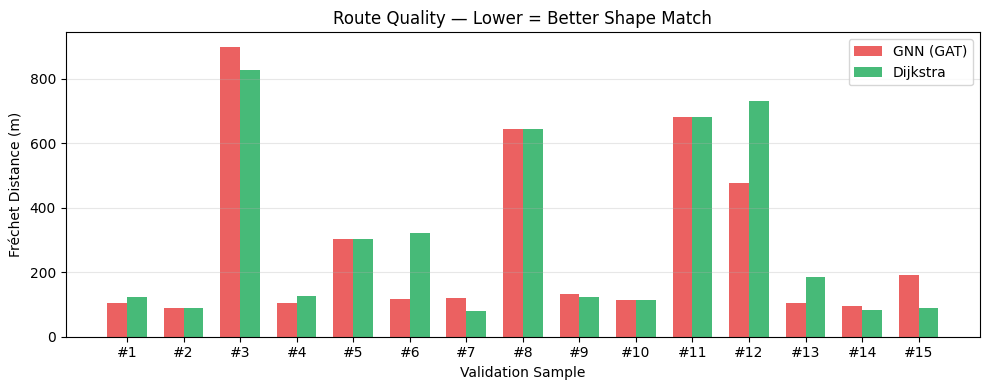

In [25]:
# ──────────────────────────────────────────────────────────────────
# 8.3  Fréchet comparison bar chart
# ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(N_EVAL)
w = 0.35
ax.bar(x - w/2, frechet_gnn, w, label="GNN (GAT)", color="#E84545", alpha=0.85)
ax.bar(x + w/2, frechet_dij, w, label="Dijkstra",  color="#27ae60", alpha=0.85)
ax.set_xlabel("Validation Sample")
ax.set_ylabel("Fréchet Distance (m)")
ax.set_title("Route Quality — Lower = Better Shape Match")
ax.set_xticks(x)
ax.set_xticklabels([f"#{i+1}" for i in range(N_EVAL)])
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


── Sample 1 ──


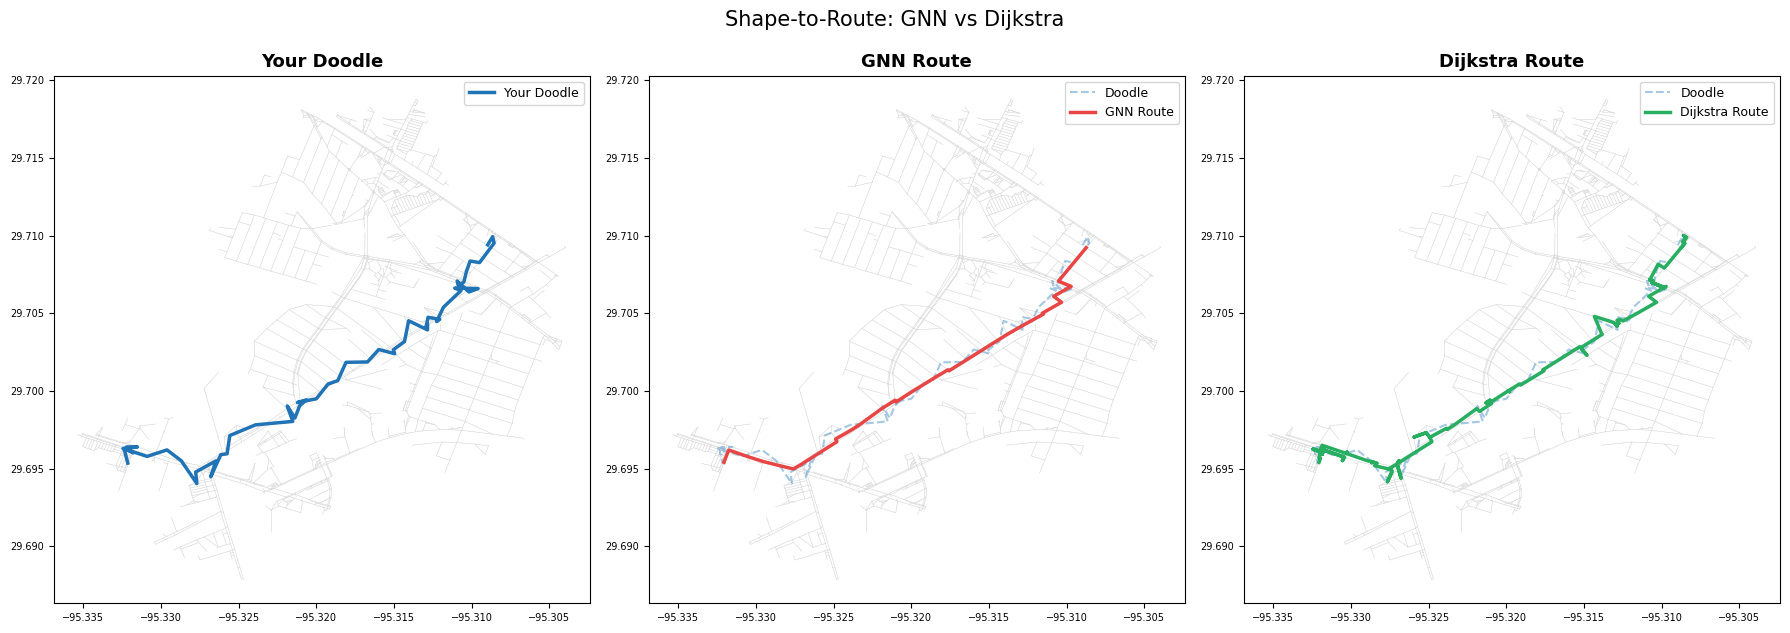


── Sample 2 ──


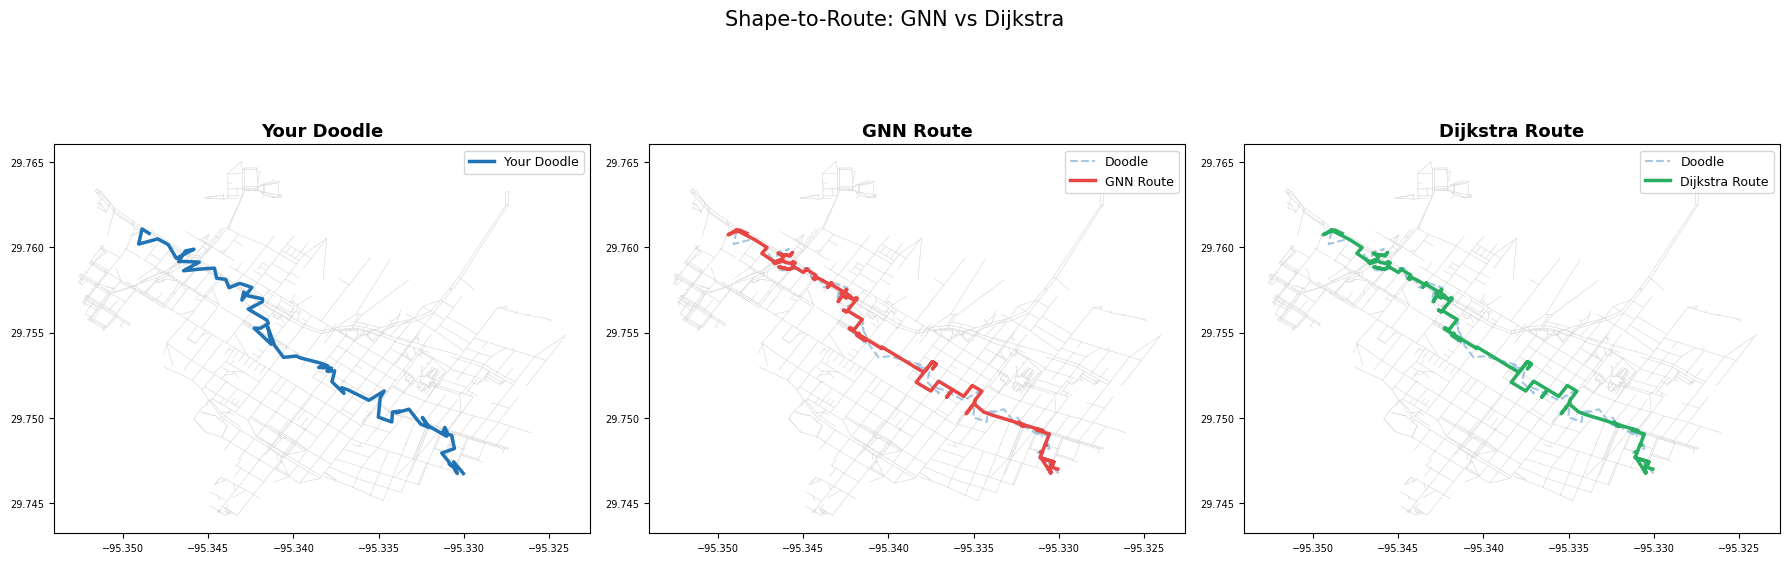


── Sample 3 ──


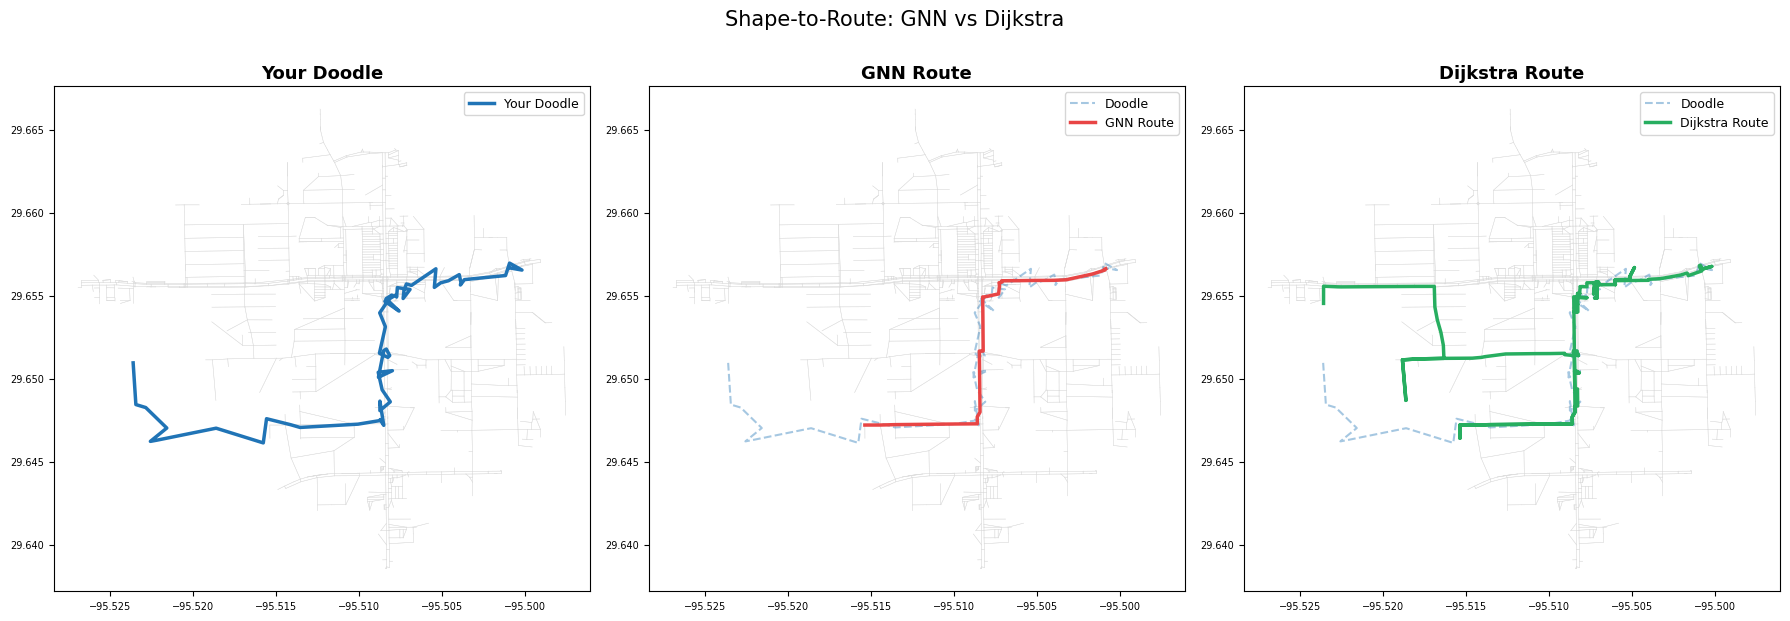

In [26]:
# ──────────────────────────────────────────────────────────────────
# 8.4  Side-by-side route visualisation (matplotlib)
# ──────────────────────────────────────────────────────────────────

def plot_comparison(sample, G_local):
    doodle = sample.doodle_coords
    gnn_r  = gnn_predict_route(model, G_local, doodle)
    dij_r  = dijkstra_route(G_local, doodle)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, route, color, title in [
        (axes[0], doodle, "#2074b6", "Your Doodle"),
        (axes[1], gnn_r,  "#E84545", "GNN Route"),
        (axes[2], dij_r,  "#27ae60", "Dijkstra Route"),
    ]:
        # Road network background
        for u, v, _ in G_local.edges(data=True):
            ax.plot([G_local.nodes[u]["x"], G_local.nodes[v]["x"]],
                    [G_local.nodes[u]["y"], G_local.nodes[v]["y"]],
                    color="#ddd", linewidth=0.3, zorder=1)

        # Doodle reference on all panels
        if route != doodle:
            dlats, dlons = zip(*doodle)
            ax.plot(dlons, dlats, "#2074b6", lw=1.5, ls="--", alpha=0.4,
                    label="Doodle", zorder=2)

        if route:
            rlats, rlons = zip(*route)
            ax.plot(rlons, rlats, color, lw=2.5, label=title, zorder=3)

        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.legend(loc="upper right", fontsize=9)
        ax.set_aspect("equal")
        ax.tick_params(labelsize=7)

    plt.suptitle("Shape-to-Route: GNN vs Dijkstra", fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()


# Plot 3 validation samples
for i in range(min(3, len(val_data))):
    print(f"\n── Sample {i+1} ──")
    plot_comparison(val_data[i], val_data[i].subgraph_ref)

In [29]:
# ──────────────────────────────────────────────────────────────────
# 8.5  Interactive Folium comparison map
# ──────────────────────────────────────────────────────────────────

def folium_comparison(sample, G_local):
    """Interactive Folium map with all three routes overlaid."""
    doodle = sample.doodle_coords
    gnn_r  = gnn_predict_route(model, G_local, doodle)
    dij_r  = dijkstra_route(G_local, doodle)

    lats = [p[0] for p in doodle]
    lons = [p[1] for p in doodle]
    center = [(min(lats)+max(lats))/2, (min(lons)+max(lons))/2]

    m = folium.Map(location=center, zoom_start=15, tiles="CartoDB positron")

    folium.PolyLine(doodle, color="#2074b6", weight=3, opacity=0.6,
                    dash_array="8 5", tooltip="Doodle").add_to(m)
    if gnn_r:
        folium.PolyLine(gnn_r, color="#E84545", weight=5, opacity=0.9,
                        tooltip=f"GNN — {route_km(gnn_r):.2f} km").add_to(m)
    if dij_r:
        folium.PolyLine(dij_r, color="#27ae60", weight=4, opacity=0.9,
                        tooltip=f"Dijkstra — {route_km(dij_r):.2f} km").add_to(m)

    folium.Marker(doodle[0], tooltip="Start",
                  icon=folium.Icon(color="green", icon="play", prefix="fa")).add_to(m)
    folium.Marker(doodle[-1], tooltip="End",
                  icon=folium.Icon(color="red", icon="flag-checkered", prefix="fa")).add_to(m)

    legend = '''
    <div style="position:fixed; bottom:30px; left:30px; z-index:9999;
                background:white; padding:12px; border-radius:8px;
                box-shadow:0 2px 6px rgba(0,0,0,.3); font-size:13px;">
        <b>Legend</b><br>
        <span style="color:#2074b6;">━ ━</span> Doodle<br>
        <span style="color:#E84545;">━━━</span> GNN Route<br>
        <span style="color:#27ae60;">━━━</span> Dijkstra Route
    </div>'''
    m.get_root().html.add_child(folium.Element(legend))
    return m

# Show first validation sample
folium_comparison(val_data[0], val_data[0].subgraph_ref)

---
## 9 · Export & Scaling for Real-World Usage

### GPX / KML Export
The functions below are carried over from your `app.py` so routes can be
downloaded and loaded into Strava, Garmin, etc.

In [ ]:
# ──────────────────────────────────────────────────────────────────
# 9.1  GPX / KML export (same as your app.py)
# ──────────────────────────────────────────────────────────────────

def to_gpx(coords, name="RouteDoodle-GNN"):
    pts = "\n".join(f'    <trkpt lat="{lat:.7f}" lon="{lon:.7f}"/>'
                    for lat, lon in coords)
    return (
        '<?xml version="1.0" encoding="UTF-8"?>\n'
        '<gpx version="1.1" creator="RouteDoodle-GNN" '
        'xmlns="http://www.topografix.com/GPX/1/1">\n'
        f'  <trk><name>{name}</name><trkseg>\n{pts}\n  </trkseg></trk>\n</gpx>'
    )

def to_kml(coords, name="RouteDoodle-GNN"):
    cs = " ".join(f"{lon:.7f},{lat:.7f},0" for lat, lon in coords)
    return (
        '<?xml version="1.0" encoding="UTF-8"?>\n'
        '<kml xmlns="http://www.opengis.net/kml/2.2"><Document>\n'
        f'  <name>{name}</name>\n'
        f'  <Placemark><LineString><coordinates>{cs}'
        '</coordinates></LineString></Placemark>\n</Document></kml>'
    )


# Example: export the first validation sample's GNN route
sample = val_data[0]
gnn_r = gnn_predict_route(model, sample.subgraph_ref, sample.doodle_coords)
if gnn_r:
    with open("route_gnn.gpx", "w") as f:
        f.write(to_gpx(gnn_r))
    with open("route_gnn.kml", "w") as f:
        f.write(to_kml(gnn_r))
    print(f"✅ Exported: route_gnn.gpx and route_gnn.kml ({route_km(gnn_r):.2f} km)")

In [ ]:
from google.colab import runtime
runtime.unassign()

### Scaling to Production

| Area | Approach |
|------|----------|
| **Real training data** | Collect actual user doodle→route pairs from the app; initially label with Dijkstra/A*, then fine-tune on whether users actually followed the route |
| **Multi-city** | Train on graphs from multiple cities — the GAT learns *relational* patterns (node proximity to doodle, degree, length), not absolute coordinates, so it generalises |
| **Richer edge features** | Road type (path/residential/highway), surface quality, elevation, lighting, safety ratings |
| **User preferences** | Encode runner history as a conditioning vector — "prefers parks", "avoids hills" |
| **RL fine-tuning** | After supervised pre-training, add a reward signal from user satisfaction (route completion rate, ratings) |
| **Deployment** | Cache city graphs in Redis; quantise the GAT to INT8 for ~3× CPU speedup; export to ONNX for mobile inference |
| **Architecture** | `Mobile App → FastAPI server → TorchServe (GNN) + Redis (graph cache)` |

### Libraries Reference

| Library | Version | Role |
|---------|---------|------|
| `osmnx` | ≥1.6 | Download + manipulate OSM graphs |
| `networkx` | ≥3.0 | Graph algorithms (Dijkstra, components) |
| `torch` | ≥2.0 | Deep learning |
| `torch-geometric` | ≥2.4 | GNN layers + graph data |
| `ipyleaflet` | ≥0.18 | Interactive map with drawing tools in Jupyter |
| `shapely` | ≥2.0 | Geometric distance computations |
| `folium` | ≥0.15 | Interactive map visualisations |
| `matplotlib` | ≥3.7 | Static plots |

---
## ✅ Summary

This notebook gives you a **complete end-to-end pipeline**:

1. **Full Houston graph** — downloaded once, cached to disk, covers every walkable street
2. **Synthetic training data** — 200 doodle→route pairs sampled across all of Houston
3. **GAT model** — 3-layer Graph Attention Network that scores every road edge
4. **Interactive drawing UI** — draw any shape on the map, snap with GNN or Dijkstra, compare both
5. **Evaluation** — Fréchet distance benchmarks + side-by-side visual comparison
6. **Export** — GPX/KML files for Strava, Garmin, etc.

The interactive map in **Section 7** replicates the drawing experience from your
Streamlit `app.py` — but now with a GNN-powered routing option alongside the
original Dijkstra baseline. 🎨🏃